### Wykrywanie naczyń z użyciem filtra soto
Stanisław Marszałek 160167 </br>
Łukasz Przykłota 159440

### Importing libraries and creating constans

In [29]:
import numpy as np
from copy import deepcopy
import os 
import ipywidgets as widgets
from IPython.display import display
import warnings

from image_processing import read_img,show_img,draw_vessels
from classic_version import classic_vessel_segmentation
from simple_statistics import create_confusions_matrix

#Supressing warrnigns
warnings.filterwarnings("ignore")

#CONSTANTS
INPUT_DIR:str="./images"
MANUAL_DIR:str="./manual1"
MASK_DIR:str="./mask"

#PATHS
input_images=[INPUT_DIR+"/"+file.name for file in os.scandir(INPUT_DIR) if file.is_file()]
manual_images=[MANUAL_DIR+"/"+file.name for file in os.scandir(MANUAL_DIR) if file.is_file()]
mask_images=[MASK_DIR+"/"+file.name for file in os.scandir("./mask") if file.is_file()]



### Choosing the input and the threshold

In [30]:

#Prog do ustalenia czy piksel jest biały czy czarny
threshold=widgets.FloatSlider(
    value=0.01,
    min=0.001,
    max=0.02,
    step=0.0005,
    description='Threshold value:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.4f',
    layout=widgets.Layout(width='auto')
)

cbox=widgets.Combobox(

    placeholder='Choose an image',
    options=input_images,
    description='Combobox:',
    ensure_option=True,
    disabled=False,
    layout=widgets.Layout(width='auto')
)
sliders=widgets.VBox([threshold,cbox],layout=widgets.Layout(width='45%'))
display(sliders)

### Displaying the input, found vessels and the expert image

In [35]:

mask,true_vessels=None,None
if cbox.value != "":
    data=zip(input_images,manual_images,mask_images)
    img=read_img(cbox.value)

    
    for tup in data:
        if tup[0]==cbox.value:
            mask=read_img(tup[2])
            true_vessels=read_img(tup[1])
    
    if mask is None:
        raise ValueError("Couldn't find the mask")
    
    if true_vessels is None:
        raise ValueError("Couldn't find the expert drawing")

    #Kopia do późniejszego rysowania znalezionych naczyń      
    img_copy=deepcopy(img)
    
    vessels=classic_vessel_segmentation(img,mask,threshold=threshold.value)
    
    true_vessels=true_vessels[:,:,1]
    #Zamiana wartosci z maski z 0 255 na 0 1
    true_vessels=np.where(true_vessels>0,1,0)

    input_image_out = widgets.Output()
    with input_image_out:
        show_img(img,"input image")

    found_vessels_out = widgets.Output()
    with found_vessels_out:
        show_img(vessels,"Foud vessles",True)

    expert_mask_out = widgets.Output()
    with expert_mask_out:
        show_img(true_vessels,"Expert mask",True)



    images_box_1 = widgets.HBox([input_image_out, found_vessels_out, expert_mask_out])
   

    display(images_box_1)


### Displaying the confusions matrix and the input image with found vessels

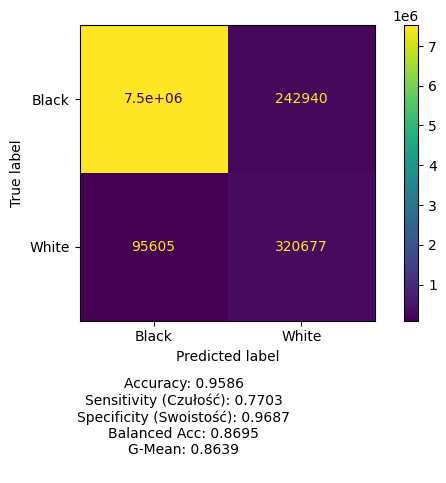

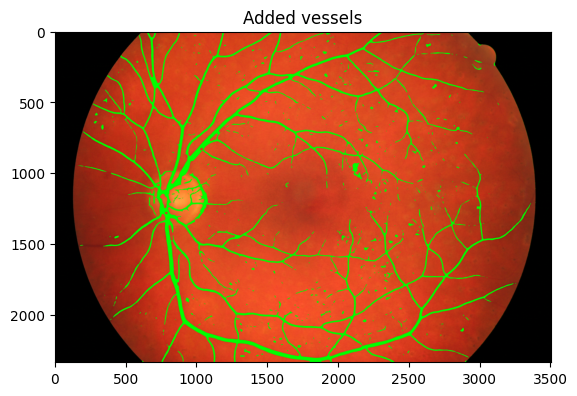

In [36]:
if mask is not None and true_vessels is not None:

     create_confusions_matrix(true_vessels,vessels)
     img=draw_vessels(img_copy,vessels)
     show_img(img,"Added vessels",False)
